In [ ]:
#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
#---
import keras_tuner as kt

In [2]:
data = pd.read_csv(r'C:\users\warbler\desktop\example/MSFT.csv', index_col='Date')
data.index = pd.to_datetime(data.index)
start = '2012-01-01'
end = '2021-12-31'
data = data[(data.index>=start) & (data.index<=end)].round(4)
print('Head:')
display(data.head())
print('Tail:')
display(data.tail())
print(len(data))

Head:


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,26.55,26.96,26.39,26.77,21.6231,64731500
2012-01-04,26.82,27.47,26.78,27.40,22.1320,80516100
2012-01-05,27.38,27.73,27.29,27.68,22.3582,56081400
2012-01-06,27.53,28.19,27.53,28.11,22.7055,99455500
2012-01-09,28.05,28.10,27.72,27.74,22.4066,59706800


Tail:


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-12-27,335.46,342.48,335.43,342.45,341.7434,19947000
2021-12-28,343.15,343.81,340.32,341.25,340.5458,15661500
2021-12-29,341.30,344.30,339.68,341.95,341.2444,15042000
2021-12-30,341.91,343.13,338.82,339.32,338.6198,15994500
2021-12-31,338.51,339.36,335.85,336.32,335.6260,18000800


2517


In [3]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2.517000e+03
mean,97.960008,98.860572,97.041279,98.011641,93.767253,3.391043e+07
std,78.223993,78.964659,77.484210,78.285287,79.451941,1.794638e+07
min,26.380000,26.630000,26.260000,26.370000,21.623100,7.425600e+06
25%,41.390000,41.740000,41.050000,41.480000,36.247900,2.281840e+07
50%,62.730000,63.150000,62.350000,62.700000,58.176800,2.962430e+07
75%,135.000000,136.370000,133.580000,135.420000,131.976900,3.954880e+07
max,344.620000,349.670000,342.200000,343.110000,342.402000,2.484285e+08


In [5]:
print('Null: ', data.Close.isna().sum())
print('Date: ', data.index.date.min(),':',data.index.date.max())
print('Close Column: ', data.Close.min(),':',data.Close.max())

Null:  0
Date:  2012-01-03 : 2021-12-31
Close Column:  26.37 : 343.11


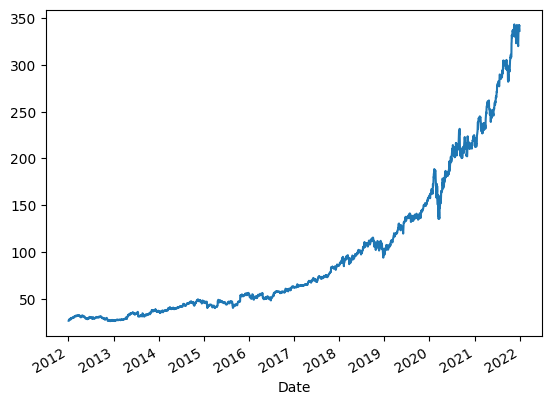

In [6]:
data.Close.plot();

In [7]:
from sklearn.preprocessing import MinMaxScaler
def preprocess_data (data , x_steps, y_steps):
    data = data.values.reshape(-1,1)
#Split Data
    train_size =  int(len(data) * 0.9)
    train_data = data[:train_size]
#---
    test_data = data[train_size - x_steps:]
#---
#Data Normalization:
    scaler = MinMaxScaler()
    train_data_sc = scaler.fit_transform(train_data)
    test_data_sc = scaler.transform(test_data)
#---
    X_train=[]
    y_train=[]
    for i in range(x_steps, len(train_data_sc)-y_steps+1):
        X_train.append(train_data_sc[i-x_steps:i, 0])
        y_train.append(train_data_sc[i:i+y_steps, 0])
    X_test=[]
    y_test=[]
    for i in range(x_steps, len(test_data_sc)-y_steps+1):
        X_test.append(test_data_sc[i-x_steps:i, 0])
        y_test.append(test_data_sc[i:i+y_steps, 0]) 

    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    return X_train[...,None], X_test[...,None], y_train, y_test, scaler
X_train, X_test, y_train, y_test , scaler = preprocess_data(data.Close, 6, 2)    

<hr />
<hr />
<hr />
<hr />

In [8]:
#Example1: SimpleRNN Model

In [9]:
def rnn_model (hp):
    num_layers = hp.Int('num_layers', 2, 6)
    model = keras.models.Sequential()
    for i in range (num_layers):
        return_seq = (i < num_layers - 1)
        model.add(keras.layers.SimpleRNN(units=hp.Int(f'units{i}',20,100,20),return_sequences=return_seq))
    model.add(keras.layers.Dense(units=2))
    lr = hp.Float('LR',1e-4, 1e-2, sampling='log')
    model.compile(loss='mae', optimizer=keras.optimizers.Adam(learning_rate=lr), metrics=['mae'])
    return model
#---
tuner_rnn = kt.BayesianOptimization(
    hypermodel=rnn_model,
    objective=kt.Objective("mae", direction="min"),
    max_trials=50,
    directory=r'C:\users\warbler\desktop\test_msft\log_rnn_model',
    overwrite=True
)
#---
tuner_rnn.search(X_train, y_train)

Trial 50 Complete [00h 00m 06s]
mae: 0.09387734532356262

Best mae So Far: 0.025062499567866325
Total elapsed time: 00h 05m 13s


In [10]:
#tuner_rnn.results_summary()

<hr />
<hr />
<hr />
<hr />

In [11]:
#Example2: Lstm Model

In [12]:
def lstm_model (hp):
    num_layers = hp.Int('num_layers', 2, 6)
    model = keras.models.Sequential()
    for i in range (num_layers):
        return_seq = (i < num_layers - 1)
        model.add(keras.layers.LSTM(units=hp.Int(f'units{i}',20,100,20),return_sequences=return_seq))
    model.add(keras.layers.Dense(units=2))
    lr = hp.Float('LR',1e-4, 1e-2, sampling='log')
    model.compile(loss='mae', optimizer=keras.optimizers.Adam(learning_rate=lr), metrics=['mae'])
    return model
#---
tuner_lstm = kt.BayesianOptimization(
    hypermodel=lstm_model,
    objective=kt.Objective("mae", direction="min"),
    max_trials=50,
    directory=r'C:\users\warbler\desktop\test_msft\log_lstm_model',
    overwrite=True
)
#---
tuner_lstm.search(X_train, y_train)



Trial 50 Complete [00h 00m 08s]
mae: 0.03530685231089592

Best mae So Far: 0.023892728611826897
Total elapsed time: 00h 08m 32s


In [13]:
#tuner_lstm.results_summary()

<hr />
<hr />
<hr />
<hr />

In [14]:
#Example3: GRU Model

In [15]:
def gru_model (hp):
    num_layers = hp.Int('num_layers', 2, 6)
    model = keras.models.Sequential()
    for i in range (num_layers):
        return_seq = (i < num_layers - 1)
        model.add(keras.layers.GRU(units=hp.Int(f'units{i}',20,100,20),return_sequences=return_seq))
    model.add(keras.layers.Dense(units=2))
    lr = hp.Float('LR',1e-4, 1e-2, sampling='log')
    model.compile(loss='mae', optimizer=keras.optimizers.Adam(learning_rate=lr), metrics=['mae'])
    return model
#---
tuner_gru = kt.BayesianOptimization(
    hypermodel=gru_model,
    objective=kt.Objective("mae", direction="min"),
    max_trials=50,
    directory=r'C:\users\warbler\desktop\test_msft\log_gru_model',
    overwrite=True
)
#---
tuner_gru.search(X_train, y_train)


Trial 50 Complete [00h 00m 12s]
mae: 0.030942706391215324

Best mae So Far: 0.02365821599960327
Total elapsed time: 00h 11m 37s


In [16]:
#tuner_gru.results_summary()

<hr />
<hr />
<hr />
<hr />

In [17]:
#Example4: GRU+LSTM(Hybrid RNN Model) 

In [18]:
def hybrid_model (hp):
    model = keras.models.Sequential()
    model.add(keras.layers.LSTM(units=hp.Int('unit_lstm',128,256,32),return_sequences=True))
    if hp.Boolean('Dropout'):
        model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.GRU(units=hp.Int('unit_gru',64,128,32)))
    model.add(keras.layers.Dense(units=2))
    lr = hp.Float('LR',1e-4, 1e-2, sampling='log')
    model.compile(loss='mae', optimizer=keras.optimizers.Adam(learning_rate=lr), metrics=['mae'])
    return model
#---
tuner_hybrid = kt.BayesianOptimization(
    hypermodel=hybrid_model,
    objective=kt.Objective("mae", direction="min"),
    max_trials=50,
    directory=r'C:\users\warbler\desktop\test_msft\log_hybrid_model',
    overwrite=True
)
#---
tuner_hybrid.search(X_train, y_train)




Trial 50 Complete [00h 00m 13s]
mae: 0.03329559043049812

Best mae So Far: 0.025949757546186447
Total elapsed time: 00h 11m 08s


In [19]:
#tuner_hybrid.results_summary()

<hr />
<hr />
<hr />
<hr />

In [20]:
#All Trainig: 
best_rnn_model = tuner_rnn.get_best_models()[0]
best_lstm_model = tuner_lstm.get_best_models()[0]
best_gru_model = tuner_gru.get_best_models()[0]
best_hybrid_model = tuner_hybrid.get_best_models()[0]
#---
best_rnn_model.fit(X_train, y_train, epochs=100, verbose=0)
best_lstm_model.fit(X_train, y_train, epochs=100, verbose=0)
best_gru_model.fit(X_train, y_train, epochs=100, verbose=0)
best_hybrid_model.fit(X_train, y_train, epochs=100, verbose=0)

C:\base\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [21]:
#Predict
y_rnn_pred = best_rnn_model.predict(X_test)
#---
y_lstm_pred = best_lstm_model.predict(X_test)
#---
y_gru_pred = best_gru_model.predict(X_test)
#---
y_hybrid_pred = best_hybrid_model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


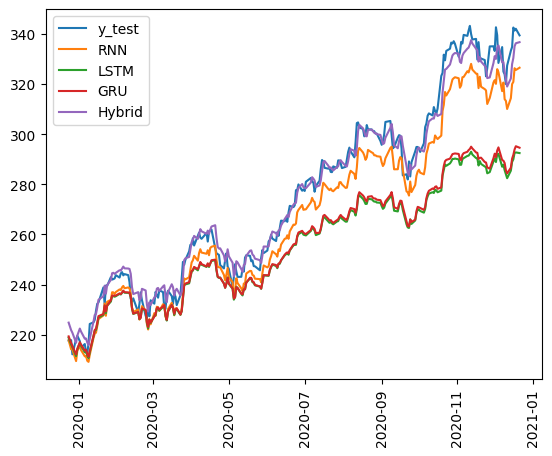

In [22]:

# plt.plot(y_test, label='actual')
# plt.plot(y_rnn_pred[:,0], label='predict')
train_size =  int(len(data) * 0.8)
train_plot = data[:train_size]
test_plot = data[train_size-6:]
plt.plot(test_plot.index[:len(y_test)],scaler.inverse_transform(y_test[:,0][...,None]), label='y_test')
plt.plot(test_plot.index[:len(y_test)],scaler.inverse_transform(y_rnn_pred[:,0][...,None]), label = 'RNN')
plt.plot(test_plot.index[:len(y_test)],scaler.inverse_transform(y_lstm_pred[:,0][...,None]), label = 'LSTM')
plt.plot(test_plot.index[:len(y_test)],scaler.inverse_transform(y_gru_pred[:,0][...,None]), label = 'GRU')
plt.plot(test_plot.index[:len(y_test)],scaler.inverse_transform(y_hybrid_pred[:,0][...,None]), label = 'Hybrid')
plt.tick_params(axis='x', rotation=90)
plt.legend()